# Preparação dos dados — Preços de combustíveis em Portugal (DGEG)

**Projeto:** O Preço da Guerra 
**Autor:** Luis Miguel Pereira Silva · PG60390 
**Universidade:** Universidade do Minho — Mestrado em IA 
**Disciplina:** SVDC 

---

## Fonte

[Direção-Geral de Energia e Geologia (DGEG)](https://www.dgeg.gov.pt/) — 
*Histórico UE* (Weekly Oil Bulletin). Frequência semanal (à 2.ª feira).

Ficheiro original: `data/dgeg-pcr-2004-2026_18_pt.xlsx`, sheet `Histórico UE` 
Ficheiro produzido: `data/precos_combustiveis_pt.csv`

## Estrutura do xlsx

O ficheiro DGEG tem um layout *human-readable* e nada *machine-readable*:

- Linhas 0–10: cabeçalho descritivo (instituição, periodicidade, etc.)
- Linha 11: `Gasóleo rodoviário` ... `Gasolina 95`
- Linha 12: sub-header `PST | ISP+Out. | IVA | PVP`
- Linha 13: `Data | €/litro | ... | Data | €/litro | ...`
- Linhas 14+: dados reais (gasóleo nas colunas 0–4, gasolina nas colunas 6–10)

Ou seja: **duas tabelas lado a lado**, cada uma com a sua coluna `Data`.
Vamos extrair só o PVP (preço de venda ao público) de cada combustível e fundir num único CSV em formato *long*.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
XLSX = RAW / 'dgeg-pcr-2004-2026_18_pt.xlsx'


## 1. Ler a sheet em modo *raw* (sem header)


In [2]:
raw = pd.read_excel(XLSX, sheet_name='Histórico UE', header=None)
print('Shape:', raw.shape)
raw.head(15)


Shape: (592, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Direção Geral de Energia e Geologia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Direção de Serviços de Planeamento Energético ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Divisão de Estatística e Mercados,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Periodicidade: semanal (3ª feira),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Última atualização: 28 de abril de 2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Estrutura dos Preços Médios e Taxas (à 2º feir...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Informação enviada à Comissão Europeia (Weekly...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Extrair as duas sub-tabelas

Os dados começam na linha 14 (índice 14, depois do header de 4 linhas).
- Gasóleo : `Data` em col 0, `PVP €/litro` em col 4
- Gasolina: `Data` em col 6, `PVP €/litro` em col 10


In [3]:
DATA_START = 14

diesel = raw.iloc[DATA_START:, [0, 4]].copy()
diesel.columns = ['date', 'gasoleo_pvp_eur_l']

gasolina = raw.iloc[DATA_START:, [6, 10]].copy()
gasolina.columns = ['date', 'gasolina95_pvp_eur_l']

# Tipos certos
for df_ in (diesel, gasolina):
    df_['date'] = pd.to_datetime(df_['date'], errors='coerce')
    val_col = [c for c in df_.columns if c != 'date'][0]
    df_[val_col] = pd.to_numeric(df_[val_col], errors='coerce')
    df_.dropna(inplace=True)

print(f'Gasóleo: {len(diesel)} semanas, {diesel.date.min().date()} → {diesel.date.max().date()}')
print(f'Gasolina: {len(gasolina)} semanas, {gasolina.date.min().date()} → {gasolina.date.max().date()}')


Gasóleo: 578 semanas, 2015-04-20 → 2026-04-27
Gasolina: 578 semanas, 2015-04-20 → 2026-04-27


## 3. Merge — uma única tabela alinhada por data

Em princípio as datas batem certo (publicação semanal conjunta), mas fazemos um *outer join* defensivo.


In [4]:
merged = pd.merge(diesel, gasolina, on='date', how='outer').sort_values('date').reset_index(drop=True)
merged.head()


,date,gasoleo_pvp_eur_l,gasolina95_pvp_eur_l
0,2015-04-20,1.227,1.485
1,2015-04-27,1.242,1.500
2,2015-05-04,1.244,1.507
3,2015-05-11,1.250,1.505
4,2015-05-18,1.249,1.502


In [5]:
# Validação — devem coincidir 100%
missing = merged[merged.isna().any(axis=1)]
print(f'Datas com algum valor em falta: {len(missing)}')
merged.tail()


Datas com algum valor em falta: 0


,date,gasoleo_pvp_eur_l,gasolina95_pvp_eur_l
579,2026-03-30,2.072,1.917
580,2026-04-06,2.131,1.938
581,2026-04-13,2.083,1.911
582,2026-04-20,1.980,1.899
583,2026-04-27,1.958,1.927


## 4. Visualizar para confirmar


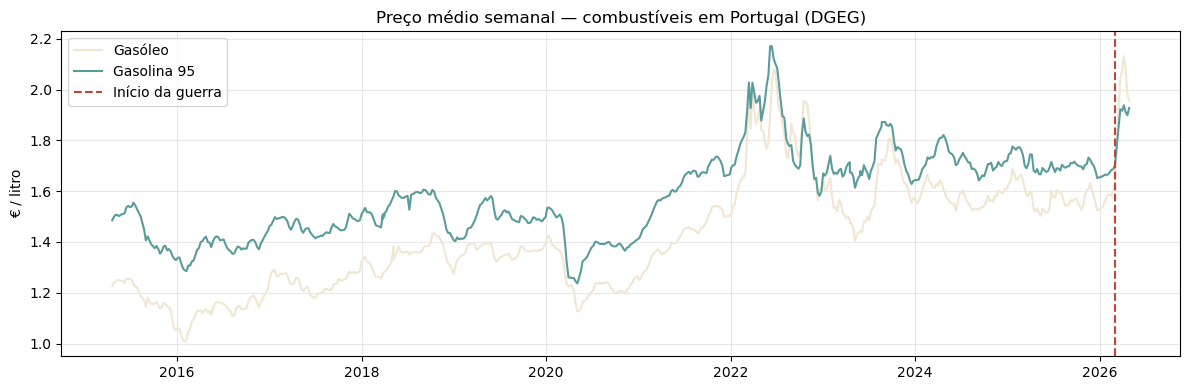

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(merged.date, merged.gasoleo_pvp_eur_l, label='Gasóleo', color='#f0e6d2')
ax.plot(merged.date, merged.gasolina95_pvp_eur_l, label='Gasolina 95', color='#5a9b9c')
ax.axvline(pd.Timestamp('2026-02-28'), color='#c44536', linestyle='--', label='Início da guerra')
ax.set_ylabel('€ / litro')
ax.set_title('Preço médio semanal — combustíveis em Portugal (DGEG)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Métricas-chave (calculadora da Secção V)

O JS guarda dois preços de referência: **antes** (semana de 26 jan 2026) e **agora** (última semana disponível). 
Confirmamos os valores aqui.


In [7]:
ref_before = merged[merged.date == '2026-01-26'].iloc[0]
ref_after  = merged.iloc[-1]

print('Antes da guerra (26 jan 2026):')
print(f'  Gasóleo  : €{ref_before.gasoleo_pvp_eur_l:.3f}/L')
print(f'  Gasolina : €{ref_before.gasolina95_pvp_eur_l:.3f}/L')
print(f'Mais recente ({ref_after.date.date()}):')
print(f'  Gasóleo  : €{ref_after.gasoleo_pvp_eur_l:.3f}/L')
print(f'  Gasolina : €{ref_after.gasolina95_pvp_eur_l:.3f}/L')


Antes da guerra (26 jan 2026):
  Gasóleo  : €1.573/L
  Gasolina : €1.665/L
Mais recente (2026-04-27):
  Gasóleo  : €1.958/L
  Gasolina : €1.927/L


## 6. Exportar CSV final


In [8]:
out = PROCESSED / 'precos_combustiveis_pt.csv'
merged.to_csv(out, index=False)
print('✓ Gravado em', out)
print(f'  ({len(merged)} semanas)')


✓ Gravado em ..\data\precos_combustiveis_pt.csv
  (584 semanas)


---

## ✓ Resultado

`data/precos_combustiveis_pt.csv` com colunas `date, gasoleo_pvp_eur_l, gasolina95_pvp_eur_l`.
Consumido por `drawPrices()` no `js/main.js` (linha laranja vs Brent).
